In [ ]:
from torch.utils.tensorboard import SummaryWriter
import os
# logs for tensorboards
log_dir = "runs/cifar10_experiments"
os.makedirs(log_dir, exist_ok=True)

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
# We defined transformation for the training and test sets
# and randomly crops the images for 32x32 pixels and flip the images
# with default probablity of 0.5 so the model can learn invariant orietations
# then it converts the the array into a tensor and scales the pixel values
# from [0,255] to [0.0,1.0]
# then we normalize the pixels of the pictures
# the first tuple is mean and the second is standard deviation
# it extract the mean from the pixels then divided it by standard deviation
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    # Removed transforms.Resize((224, 224)) for the custom Net model
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    # Removed transforms.Resize((224, 224)) for the custom Net model
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

# download the CIFAR10 dataset and apply transfom train to all of the images
trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform_train
)
# we chose 128 batch size because a bigger batch can cause more efficient
# GPU performance because it works parallel and it also give us more
# stable gradient
# and we use 2 workers, it means subprocesses to speed up data loading
# by performing it in parallel
trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=128,
    shuffle=True,
    num_workers=2
)

# download and load the CIFAR-10 test dataset
testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform_test
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=128,
    shuffle=False,
    num_workers=2
)

# define 10 classes
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

We downloaded and prepare the CIFAR-10 dataset which is avaible in Pytorch
We completed the dataset with random crops, horizontal flips and normalized just for training

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.71453285..1.8183348].


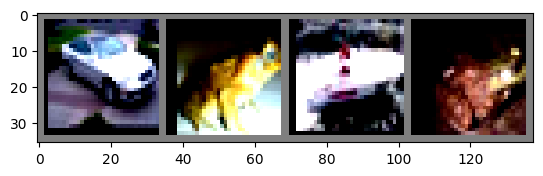

car   frog  ship  frog 


In [ ]:
# show image and unormalize
def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images[:4]))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

We defined a simple CNN withc convolutional layers, max pools and connected layers. We used LeakyRelu as activation function

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
# we defined cnn and it will sort images into 10 categories
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        # kernel is 5 in conv1 and conv2
        # so the flattened size before fc1 is 16 channels * 5 * 5 = 400
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
# we defined leaky relu and convert the output of convolutional layer
# into 1 dimensional vector (torch flatten)
    def forward(self, x):
        x = self.pool(F.leaky_relu(self.conv1(x)))
        x = self.pool(F.leaky_relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.leaky_relu(self.fc1(x))
        x = F.leaky_relu(self.fc2(x))
        x = self.fc3(x)
        return x

net_leakyrelu_sgd = Net()

In [ ]:
import torch.optim as optim
# we ue entropy for classification task it gives a number which determines how wrong
# the network is and we use SGD optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net_leakyrelu_sgd.parameters(), lr=0.0001, momentum=0.9)

SGD vs. Adam
SGD is a simple and reliable optimizer but it is slow it uses the same learning rate for every step. If the learning rate is too high it can overshoot the goal if it is too low training takes forever

Adam is a smart optimizer it can calculate an individual adaptive learning rate for every parameter. Usually it results in much faster convergence than SGD which makes it very popular for fast prototyping

We are uing SGD optimizer with a learning rate of 0.0001 and momentum of 0.9 to train the Net model

In [ ]:
num_epochs = 10

# Check if CUDA is available and move model to GPU if it is
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
net_leakyrelu_sgd.to(device)
print(f"Net (LeakyReLU+SGD) moved to {device}")

# Initialize SummaryWriter for LeakyReLU+SGD model
writer_sgd = SummaryWriter(log_dir + '/LeakyReLU_SGD')

# we train the leakyrelu nueral network
for epoch in range(num_epochs):
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device) # Move data to GPU

        optimizer.zero_grad()

        outputs = net_leakyrelu_sgd(inputs)
        loss = criterion(outputs, labels)  # compares the outputs with the original labels
        #and gives a number how bad was the network on the current batch
        loss.backward() # determine the gradient of loss
        optimizer.step()

        running_loss += loss.item()
        # Log training loss to TensorBoard
        writer_sgd.add_scalar('training loss (LeakyReLU+SGD)', loss.item(), epoch * len(trainloader) + i)

        if i % 200 == 199:    # print out every 200th batch to see how is the training going
            print(f'Epoch [{epoch + 1}/{num_epochs}], Batch [{i + 1}/{len(trainloader)}] loss: {running_loss / 200:.3f}')
            running_loss = 0.0

print('Finished Training LeakyReLU+SGD')
writer_sgd.close()

Net (LeakyReLU+SGD) moved to cpu
Epoch [1/10], Batch [200/391] loss: 2.303
Epoch [2/10], Batch [200/391] loss: 2.302
Epoch [3/10], Batch [200/391] loss: 2.300
Epoch [4/10], Batch [200/391] loss: 2.299
Epoch [5/10], Batch [200/391] loss: 2.297
Epoch [6/10], Batch [200/391] loss: 2.296
Epoch [7/10], Batch [200/391] loss: 2.293
Epoch [8/10], Batch [200/391] loss: 2.290
Epoch [9/10], Batch [200/391] loss: 2.286
Epoch [10/10], Batch [200/391] loss: 2.281
Finished Training LeakyReLU+SGD


In [ ]:
correct = 0
total = 0
# we are not training so we do not need to calculate gradient
# we calculate the outputs by running images through the network
# we chose the class with the highest energy for prediction
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net_leakyrelu_sgd(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct / total:.2f}%')

Accuracy of the network on the 10000 test images: 15.72%


We created a new instance of our Net model to train Adam optimizer with a learning rate of 0.0001

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# redefine Net class for this cell's scope becuse it was not defined
# in this kernel
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.leaky_relu(self.conv1(x)))
        x = self.pool(F.leaky_relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.leaky_relu(self.fc1(x))
        x = F.leaky_relu(self.fc2(x))
        x = F.leaky_relu(self.fc3(x))
        return x

# We try to move to gpu if there is no avaible gpu we stay on cpu
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

net_leakyrelu_adam = Net()
net_leakyrelu_adam.to(device)
# define Adam
criterion_adam = nn.CrossEntropyLoss()
optimizer_adam = optim.Adam(net_leakyrelu_adam.parameters(), lr=0.0001)

num_epochs_adam = 10
print(f"Net (LeakyReLU+Adam) moved to {device}")

# SummaryWriter for LeakyReLU+Adam model
writer_adam = SummaryWriter(log_dir + '/LeakyReLU_Adam')

print("Starting training with Adam optimizer...")
for epoch in range(num_epochs_adam):
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_adam.zero_grad()

        outputs = net_leakyrelu_adam(inputs)
        loss = criterion_adam(outputs, labels)
        loss.backward()
        optimizer_adam.step()

        running_loss += loss.item()
        # log training loss to tensorboard
        writer_adam.add_scalar('training loss (LeakyReLU+Adam)', loss.item(), epoch * len(trainloader) + i)

        if i % 200 == 199:
            print(f'Epoch [{epoch + 1}/{num_epochs_adam}], Batch [{i + 1}/{len(trainloader)}] loss: {running_loss / 200:.3f}')
            running_loss = 0.0

print('Finished Training LeakyReLU+Adam')
writer_adam.close()

Net (LeakyReLU+Adam) moved to cpu
Starting training with Adam optimizer...
Epoch [1/10], Batch [200/391] loss: 2.239
Epoch [2/10], Batch [200/391] loss: 1.892
Epoch [3/10], Batch [200/391] loss: 1.764
Epoch [4/10], Batch [200/391] loss: 1.703
Epoch [5/10], Batch [200/391] loss: 1.664
Epoch [6/10], Batch [200/391] loss: 1.643
Epoch [7/10], Batch [200/391] loss: 1.618
Epoch [8/10], Batch [200/391] loss: 1.578
Epoch [9/10], Batch [200/391] loss: 1.559
Epoch [10/10], Batch [200/391] loss: 1.541
Finished Training LeakyReLU+Adam


In [ ]:
import torch
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

correct_adam = 0
total_adam = 0

print("Evaluating Net with Adam optimizer...")
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        outputs = net_leakyrelu_adam(images)
        _, predicted = torch.max(outputs.data, 1)
        total_adam += labels.size(0)
        correct_adam += (predicted == labels).sum().item()

print(f'Accuracy of Net with Adam optimizer on the 10000 test images: {100 * correct_adam / total_adam:.2f}%')

Evaluating Net with Adam optimizer...
Accuracy of Net with Adam optimizer on the 10000 test images: 47.55%


We defined a new CNN model which uses Tanh activation functions instead of LeakyRelu. We trained it with SGD optimizer to observe the effect of activation function

LeakyReLU vs. Tanh
Tanh is a sigmoid-like function that pushes values between -1 and 1. Its main disadvantage is the vanishing gradient problem. At the edges of the function the gradient becomes almost zero which means the network stops learning

LeakyRelu isthe  modern standard unlike the regular ReLU it allows a small leak in the negative range which helps to prevent neurons from dying during the training process so the model still can learn

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# define Tanh
class NetTanh(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(torch.tanh(self.conv1(x)))
        x = self.pool(torch.tanh(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        x = torch.tanh(self.fc3(x))
        return x

net_tanh_sgd = NetTanh()
net_tanh_sgd.to(device)

criterion_tanh = nn.CrossEntropyLoss()
optimizer_tanh = optim.SGD(net_tanh_sgd.parameters(), lr=0.0001, momentum=0.9)

num_epochs_tanh = 10
print(f"Net (Tanh+SGD) moved to {device}")

# summaryWriter for Tanh+SGD model
writer_tanh = SummaryWriter(log_dir + '/Tanh_SGD')

print("Starting training with Tanh activation and SGD optimizer...")
for epoch in range(num_epochs_tanh):
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_tanh.zero_grad()

        outputs = net_tanh_sgd(inputs)
        loss = criterion_tanh(outputs, labels)
        loss.backward()
        optimizer_tanh.step()

        running_loss += loss.item()
        # loging
        writer_tanh.add_scalar('training loss (Tanh+SGD)', loss.item(), epoch * len(trainloader) + i)

        if i % 200 == 199:
            print(f'Epoch [{epoch + 1}/{num_epochs_tanh}], Batch [{i + 1}/{len(trainloader)}] loss: {running_loss / 200:.3f}')
            running_loss = 0.0

print('Finished Training Tanh+SGD')
writer_tanh.close()

Net (Tanh+SGD) moved to cpu
Starting training with Tanh activation and SGD optimizer...
Epoch [1/10], Batch [200/391] loss: 2.302
Epoch [2/10], Batch [200/391] loss: 2.292
Epoch [3/10], Batch [200/391] loss: 2.280
Epoch [4/10], Batch [200/391] loss: 2.268
Epoch [5/10], Batch [200/391] loss: 2.251
Epoch [6/10], Batch [200/391] loss: 2.232
Epoch [7/10], Batch [200/391] loss: 2.215
Epoch [8/10], Batch [200/391] loss: 2.192
Epoch [9/10], Batch [200/391] loss: 2.175
Epoch [10/10], Batch [200/391] loss: 2.158
Finished Training Tanh+SGD


In [ ]:
import torch

# Ensure 'device' is defined for this cell
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

correct_tanh = 0
total_tanh = 0

print("Evaluating Net with Tanh activation...")
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        outputs = net_tanh_sgd(images)
        _, predicted = torch.max(outputs.data, 1)
        total_tanh += labels.size(0)
        correct_tanh += (predicted == labels).sum().item()

print(f'Accuracy of Net with Tanh activation on the 10000 test images: {100 * correct_tanh / total_tanh:.2f}%')

Evaluating Net with Tanh activation...
Accuracy of Net with Tanh activation on the 10000 test images: 24.22%


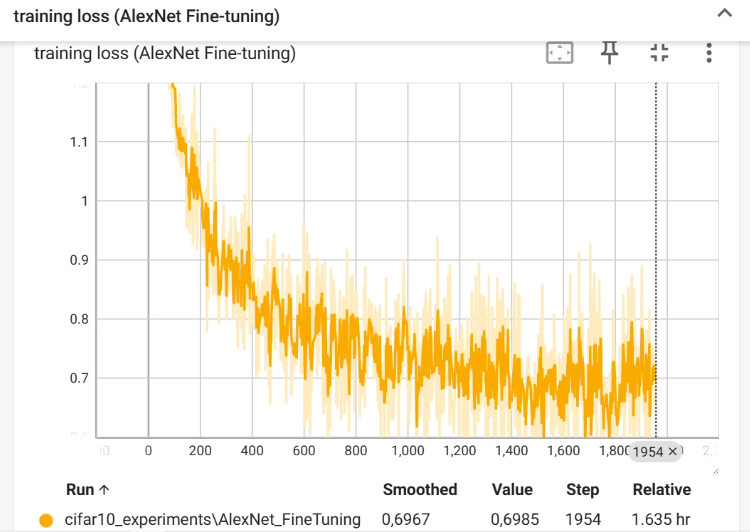

Trend:  training loss shows a clear downward trajectory, indicating that the model is successfully learning from the CIFAR-10 dataset.
Convergence: After step 1400 the loss curve starts to flatten out suggesting that the model is reaching convergence
Noise and Variance: The light yellow shaded area represents the raw loss values, showing noise
Final Performance: At step 1954 the smoothed loss is around 0.6967. This suggests that while the model has improved significantly from the starting point there might still be room for more tuning or more epochs to reach a lower error rate

The original AlexNet was invented for ImageNet dataset witch 1000 different category so the original output layer included 1000 neurons but in the CIFAR-10 we only have 10 classes so we need to change the last layer

In [ ]:
import torchvision.models as models
# we are loading a pre-trained AlexNet model and modifier the classifier for CIFAR-10
alexnet = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)

# the last layer is the 6th which originally outputs 1000 classes but we change it for 10
alexnet.classifier[6] = nn.Linear(alexnet.classifier[6].in_features, 10)

# freeze every parameters except the final layer
for param in alexnet.parameters():
    param.requires_grad = False
# unfreeze the parameters in the new final layer for fine-tuning
for param in alexnet.classifier[6].parameters():
    param.requires_grad = True


In [ ]:
print('AlexNet-specifikus adatátalakítások és adatbetöltők újbóli definiálása...')

# AlexNet-specifikus átalakítások
transform_alexnet_train = transforms.Compose([
    transforms.Resize((224, 224)), # AlexNet expected input size
    transforms.RandomCrop(224, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_alexnet_test = transforms.Compose([
    transforms.Resize((224, 224)), # AlexNet expected input size
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

# AlexNet-specifikus adatbetöltők
trainset_alexnet = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform_alexnet_train
)
trainloader_alexnet = torch.utils.data.DataLoader(
    trainset_alexnet,
    batch_size=128,
    shuffle=True,
    num_workers=2
)

testset_alexnet = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform_alexnet_test
)
testloader_alexnet = torch.utils.data.DataLoader(
    testset_alexnet,
    batch_size=128,
    shuffle=False,
    num_workers=2
)

print('AlexNet-specifikus adatbetöltők sikeresen újbóli definiálva.')

AlexNet-specifikus adatátalakítások és adatbetöltők újbóli definiálása...
AlexNet-specifikus adatbetöltők sikeresen újbóli definiálva.


In [ ]:
# we defined criterion and optimizer for AlexNet fine-tuning
criterion_alexnet = nn.CrossEntropyLoss()
optimizer_alexnet = optim.Adam(alexnet.parameters(), lr=0.0001)

# check if CUDA is available and move model to GPU if it is
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
alexnet.to(device)
print(f"AlexNet moved to {device}")

# Initialize SummaryWriter for AlexNet model
writer_alexnet = SummaryWriter(log_dir + '/AlexNet_FineTuning')

# we worked with less epoch so it will execute faster and moved the data to GPU
num_epochs_alexnet = 5
print("Starting AlexNet fine-tuning on CIFAR-10...")
for epoch in range(num_epochs_alexnet):
    running_loss = 0.0
    for i, data in enumerate(trainloader_alexnet, 0): # Use AlexNet-specific trainloader
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_alexnet.zero_grad()

        outputs = alexnet(inputs)
        loss = criterion_alexnet(outputs, labels)
        loss.backward()
        optimizer_alexnet.step()

        running_loss += loss.item()
        # Log training loss to TensorBoard
        writer_alexnet.add_scalar('training loss (AlexNet Fine-tuning)', loss.item(), epoch * len(trainloader_alexnet) + i)

        if i % 20 == 19:
            print(f'Epoch [{epoch + 1}/{num_epochs_alexnet}], Batch [{i + 1}/{len(trainloader_alexnet)}] loss: {running_loss / 200:.3f}')
            running_loss = 0.0

print('Finished AlexNet Fine-tuning')
writer_alexnet.close()

AlexNet moved to cpu
Starting AlexNet fine-tuning on CIFAR-10...
Epoch [1/5], Batch [20/391] loss: 0.212
Epoch [1/5], Batch [40/391] loss: 0.171
Epoch [1/5], Batch [60/391] loss: 0.146
Epoch [1/5], Batch [80/391] loss: 0.130
Epoch [1/5], Batch [100/391] loss: 0.121
Epoch [1/5], Batch [120/391] loss: 0.112
Epoch [1/5], Batch [140/391] loss: 0.108
Epoch [1/5], Batch [160/391] loss: 0.103
Epoch [1/5], Batch [180/391] loss: 0.101
Epoch [1/5], Batch [200/391] loss: 0.097
Epoch [1/5], Batch [220/391] loss: 0.095
Epoch [1/5], Batch [240/391] loss: 0.095
Epoch [1/5], Batch [260/391] loss: 0.094
Epoch [1/5], Batch [280/391] loss: 0.090
Epoch [1/5], Batch [300/391] loss: 0.089
Epoch [1/5], Batch [320/391] loss: 0.090
Epoch [1/5], Batch [340/391] loss: 0.088
Epoch [1/5], Batch [360/391] loss: 0.086
Epoch [1/5], Batch [380/391] loss: 0.086
Epoch [2/5], Batch [20/391] loss: 0.085
Epoch [2/5], Batch [40/391] loss: 0.083
Epoch [2/5], Batch [60/391] loss: 0.084
Epoch [2/5], Batch [80/391] loss: 0.081


In [ ]:
correct_alexnet = 0
total_alexnet = 0

print("Evaluating AlexNet fine-tuned model...")
with torch.no_grad():
    for data in testloader_alexnet: # Use AlexNet-specific testloader
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        outputs = alexnet(images)
        _, predicted = torch.max(outputs.data, 1)
        total_alexnet += labels.size(0)
        correct_alexnet += (predicted == labels).sum().item()

print(f'Accuracy of AlexNet fine-tuned on CIFAR-10 (10000 test images): {100 * correct_alexnet / total_alexnet:.2f}%')

Evaluating AlexNet fine-tuned model...
Accuracy of AlexNet fine-tuned on CIFAR-10 (10000 test images): 76.21%


Fine-tuning vs Feature extraction

Fine-tuning: AlexNet was trained on ImageNet and CIFAR-10 also contains natural images because of this fine-tuning gives higher accuracy. Because the last layers can adapt to the specific details of CIFAR-10 the model works better. The results 76.21% prove this.


Feature Extraction: if we only use AlexNet as a feature extractor the performance on CIFAR-10 would likely be lower than the result with fine-tuning. This is because the features are not perfectly optimized for the specific objects in CIFAR-10 but it would still perform much better than a new model starting from zero because the model already learned a lot of features from ImageNet

In [ ]:
transform_mnist = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

mnist_trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform_mnist)
mnist_trainloader = torch.utils.data.DataLoader(mnist_trainset, batch_size=64, shuffle=True)

mnist_testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform_mnist)
mnist_testloader = torch.utils.data.DataLoader(mnist_testset, batch_size=64, shuffle=False)

print("MNIST dataset prepared.")

MNIST dataset prepared.


In [ ]:
# Simple CNN for MNIST (1 input channel, 10 output classes)
class NetMNIST(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.pool = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        self.fc = nn.Linear(320, 10) # Adjust input features based on image size after conv/pool

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc(x))
        return x

net_mnist = NetMNIST()
mnist_device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
net_mnist.to(mnist_device)

criterion_mnist = nn.CrossEntropyLoss()
optimizer_mnist = optim.SGD(net_mnist.parameters(), lr=0.01, momentum=0.5)

num_epochs_mnist = 5 # Reduced epochs for faster execution

# Initialize SummaryWriter for MNIST model
writer_mnist = SummaryWriter(log_dir + '/MNIST_CNN')

print("Starting CNN training on MNIST...")
for epoch in range(num_epochs_mnist):
    running_loss = 0.0
    for batch_idx, (data, target) in enumerate(mnist_trainloader):
        data, target = data.to(mnist_device), target.to(mnist_device)
        optimizer_mnist.zero_grad()
        output = net_mnist(data)
        loss = criterion_mnist(output, target)
        loss.backward()
        optimizer_mnist.step()
        running_loss += loss.item()
        # Log training loss to TensorBoard
        writer_mnist.add_scalar('training loss (MNIST CNN)', loss.item(), epoch * len(mnist_trainloader) + batch_idx)

        if batch_idx % 100 == 99:
            print(f'Epoch [{epoch + 1}/{num_epochs_mnist}], Batch [{batch_idx + 1}/{len(mnist_trainloader)}] loss: {running_loss / 100:.3f}')
            running_loss = 0.0
print('Finished Training on MNIST!')
writer_mnist.close()

Starting CNN training on MNIST...
Epoch [1/5], Batch [100/938] loss: 1.895
Epoch [1/5], Batch [200/938] loss: 1.264
Epoch [1/5], Batch [300/938] loss: 1.134
Epoch [1/5], Batch [400/938] loss: 1.106
Epoch [1/5], Batch [500/938] loss: 1.103
Epoch [1/5], Batch [600/938] loss: 1.066
Epoch [1/5], Batch [700/938] loss: 1.061
Epoch [1/5], Batch [800/938] loss: 1.065
Epoch [1/5], Batch [900/938] loss: 1.085
Epoch [2/5], Batch [100/938] loss: 1.074
Epoch [2/5], Batch [200/938] loss: 1.049
Epoch [2/5], Batch [300/938] loss: 1.029
Epoch [2/5], Batch [400/938] loss: 1.046
Epoch [2/5], Batch [500/938] loss: 1.022
Epoch [2/5], Batch [600/938] loss: 1.016
Epoch [2/5], Batch [700/938] loss: 1.030
Epoch [2/5], Batch [800/938] loss: 1.008
Epoch [2/5], Batch [900/938] loss: 1.027
Epoch [3/5], Batch [100/938] loss: 1.011
Epoch [3/5], Batch [200/938] loss: 1.025
Epoch [3/5], Batch [300/938] loss: 1.022
Epoch [3/5], Batch [400/938] loss: 0.996
Epoch [3/5], Batch [500/938] loss: 0.989
Epoch [3/5], Batch [600

In [ ]:
correct_mnist = 0
total_mnist = 0

print("Evaluating CNN on MNIST test set...")
with torch.no_grad():
    for data, target in mnist_testloader:
        data, target = data.to(mnist_device), target.to(mnist_device)
        output = net_mnist(data)
        _, predicted = torch.max(output.data, 1)
        total_mnist += target.size(0)
        correct_mnist += (predicted == target).sum().item()

print(f'Accuracy of CNN on MNIST (10000 test images): {100 * correct_mnist / total_mnist:.2f}%')


Evaluating CNN on MNIST test set...
Accuracy of CNN on MNIST (10000 test images): 67.51%


In [ ]:

transform_svhn = transforms.Compose([
    transforms.Resize((28, 28)), # Resize SVHN to match MNIST image size
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # SVHN normalization
])

svhn_trainset = torchvision.datasets.SVHN(root='./data', split='train', download=True, transform=transform_svhn)
svhn_trainloader = torch.utils.data.DataLoader(svhn_trainset, batch_size=64, shuffle=True)

svhn_testset = torchvision.datasets.SVHN(root='./data', split='test', download=True, transform=transform_svhn)
svhn_testloader = torch.utils.data.DataLoader(svhn_testset, batch_size=64, shuffle=False)

print("SVHN dataset prepared.")

SVHN dataset prepared.


In [ ]:
# Adapt NetMNIST for SVHN
# Create a new CNN architecture that expects 3 input channels.
# We will copy the weights from the trained MNIST model's convolutional layers.

class NetSVHN(nn.Module):
    def __init__(self, original_mnist_model):
        super().__init__()
        # Modify the first convolutional layer to accept 3 input channels
        # A common trick is to average or repeat the weights from the 1-channel input layer
        self.conv1 = nn.Conv2d(3, 10, kernel_size=5)

        # Initialize new conv1 weights from MNIST conv1 weights
        # We can either sum, average, or just take one channel's weights and repeat
        # For simplicity, let's replicate the single channel weights across 3 input channels
        self.conv1.weight.data = original_mnist_model.conv1.weight.data.repeat(1, 3, 1, 1)


        self.pool = original_mnist_model.pool
        self.conv2 = original_mnist_model.conv2
        self.fc = original_mnist_model.fc

        # Freeze all layers except the final fully connected layer
        for param in self.parameters():
            param.requires_grad = False

        # Unfreeze the final fully connected layer for fine-tuning on SVHN
        self.fc.weight.requires_grad = True
        self.fc.bias.requires_grad = True

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc(x))
        return x

net_svhn = NetSVHN(net_mnist) # Pass the trained MNIST model
svhn_device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
net_svhn.to(svhn_device)

criterion_svhn = nn.CrossEntropyLoss()
optimizer_svhn = optim.SGD(filter(lambda p: p.requires_grad, net_svhn.parameters()), lr=0.01, momentum=0.5)

num_epochs_svhn = 5 # Reduced epochs for faster execution

# Initialize SummaryWriter for SVHN transfer learning model
writer_svhn = SummaryWriter(log_dir + '/MNIST_to_SVHN')

print("Starting Transfer Learning (MNIST -> SVHN)...")
for epoch in range(num_epochs_svhn):
    running_loss = 0.0
    for batch_idx, (data, target) in enumerate(svhn_trainloader):
        data, target = data.to(svhn_device), target.to(svhn_device)
        optimizer_svhn.zero_grad()
        output = net_svhn(data)
        loss = criterion_svhn(output, target)
        loss.backward()
        optimizer_svhn.step()
        running_loss += loss.item()
        # Log training loss to TensorBoard
        writer_svhn.add_scalar('training loss (MNIST->SVHN Transfer Learning)', loss.item(), epoch * len(svhn_trainloader) + batch_idx)

        if batch_idx % 100 == 99:
            print(f'Epoch [{epoch + 1}/{num_epochs_svhn}], Batch [{batch_idx + 1}/{len(svhn_trainloader)}] loss: {running_loss / 100:.3f}')
            running_loss = 0.0
print('Finished Transfer Learning on SVHN!')
writer_svhn.close()

Starting Transfer Learning (MNIST -> SVHN)...
Epoch [1/5], Batch [100/1145] loss: 2.035
Epoch [1/5], Batch [200/1145] loss: 1.791
Epoch [1/5], Batch [300/1145] loss: 1.688
Epoch [1/5], Batch [400/1145] loss: 1.642
Epoch [1/5], Batch [500/1145] loss: 1.597
Epoch [1/5], Batch [600/1145] loss: 1.538
Epoch [1/5], Batch [700/1145] loss: 1.537
Epoch [1/5], Batch [800/1145] loss: 1.499
Epoch [1/5], Batch [900/1145] loss: 1.492
Epoch [1/5], Batch [1000/1145] loss: 1.459
Epoch [1/5], Batch [1100/1145] loss: 1.456
Epoch [2/5], Batch [100/1145] loss: 1.438
Epoch [2/5], Batch [200/1145] loss: 1.431
Epoch [2/5], Batch [300/1145] loss: 1.427
Epoch [2/5], Batch [400/1145] loss: 1.418
Epoch [2/5], Batch [500/1145] loss: 1.413
Epoch [2/5], Batch [600/1145] loss: 1.375
Epoch [2/5], Batch [700/1145] loss: 1.383
Epoch [2/5], Batch [800/1145] loss: 1.395
Epoch [2/5], Batch [900/1145] loss: 1.394
Epoch [2/5], Batch [1000/1145] loss: 1.371
Epoch [2/5], Batch [1100/1145] loss: 1.370
Epoch [3/5], Batch [100/11

In [ ]:
correct_svhn = 0
total_svhn = 0

print("Evaluating transferred CNN on SVHN test set...")
with torch.no_grad():
    for data, target in svhn_testloader:
        data, target = data.to(svhn_device), target.to(svhn_device)
        output = net_svhn(data)
        _, predicted = torch.max(output.data, 1)
        total_svhn += target.size(0)
        correct_svhn += (predicted == target).sum().item()

print(f'Accuracy of Transferred CNN on SVHN (test images): {100 * correct_svhn / total_svhn:.2f}%')


Evaluating transferred CNN on SVHN test set...
Accuracy of Transferred CNN on SVHN (test images): 62.62%
